# Model 1: A school of 20 fish through time

Each fish is baseline (0) or escaping (1). The mean of these binary states is the **fraction escaping**, between 0 and 1. The field is `stimulus + J * activity - threshold`. Escaping fish add positive social input; baseline fish add zero. This replaces the signed mean-spin coupling in the original brief.

During each step, baseline fish are visited in random order and activate with probability `1 / (1 + exp(-beta * field))`. Later fish see earlier activations. Any escaping fish increases the probability for those visited next; a majority is not required for positive social input. Whether a small seed grows into a cascade still depends on coupling, threshold, noise, and escape duration.

The threat pulse starts at `stimulus_start`, lasts `stimulus_duration` steps, and currently reaches **all fish**. This demonstration does not isolate responses to a small informed minority. Escapes last `escape_duration` steps. Fish already escaping at the start of a step only advance their recovery timer; they cannot reactivate that step. New escapes start their timers without immediately decrementing them. The first recorded column is the initial state; each subsequent column is the state after one update step. All fish start at baseline, and the simulation uses a fixed random seed. Run the cells in order to reset the simulation.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

from agent import Agent
from stimulus import square_wave

In [2]:
# Model parameters
n_fish = 20
total_timesteps = 100
random_seed = 2026

# Agent parameters
J = 0.5
beta = 8.0
threshold = 0.5
escape_duration = 6

# Stimulus parameters
stimulus_start = 10
stimulus_strength = 1
stimulus_duration = 2

In [3]:
# Initialise n_fish number of agents
rng = np.random.default_rng(random_seed)
agents = np.array([Agent() for _ in range(n_fish)])
for agent in agents:
    agent.spin = 0

In [4]:
# Create stimulus and state history arrays
time = np.arange(total_timesteps)
stimulus = square_wave(time - stimulus_start, stimulus_strength, stimulus_duration)
escape_timers = np.zeros(n_fish, dtype=int)
state_history = np.empty((n_fish, len(time)), dtype=np.int8)
state_history[:, 0] = [agent.spin for agent in agents]

In [5]:
# Run the simulation
for t in range(total_timesteps):
    already_escaping = np.array([agent.spin == 1 for agent in agents])
    active_count = int(already_escaping.sum())

    # Random sequential updates: the field changes after each new escape.
    for fish in rng.permutation(np.flatnonzero(~already_escaping)):
        activity = active_count / n_fish
        field = stimulus[t] + J * activity - threshold
        probability = 1 / (1 + np.exp(-beta * field))
        if rng.random() < probability:
            agents[fish].spin = 1
            escape_timers[fish] = escape_duration
            active_count += 1

    escape_timers[already_escaping] -= 1
    for fish in np.flatnonzero(already_escaping & (escape_timers == 0)):
        agents[fish].spin = 0

    state_history[:, t] = [agent.spin for agent in agents]

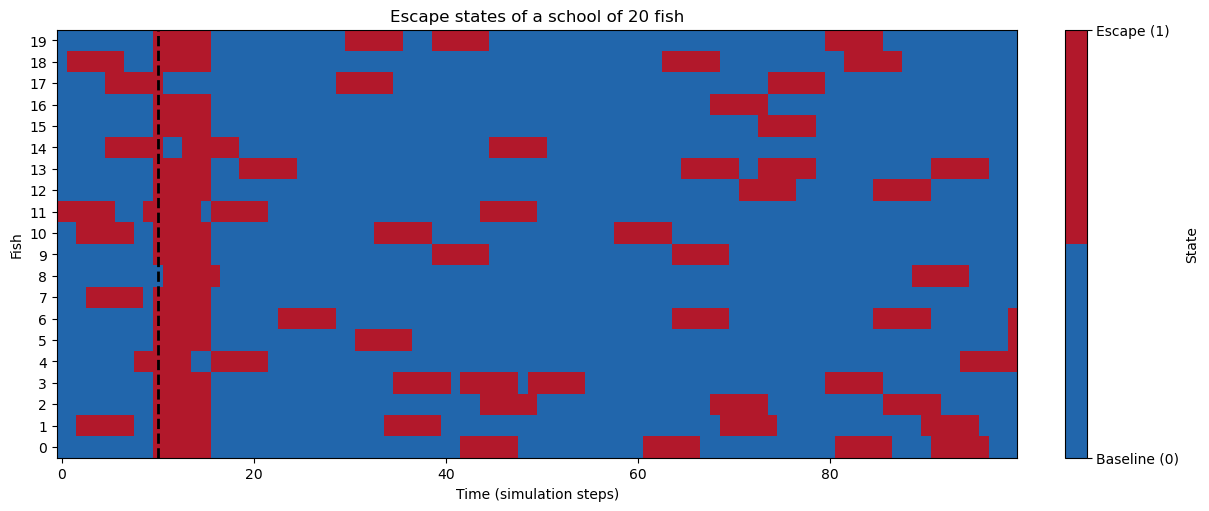

In [8]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
cmap = ListedColormap(["#2166ac", "#b2182b"])
image = ax.pcolormesh(time, np.arange(n_fish), state_history, cmap=cmap)

ax.set_yticks(np.arange(n_fish))
ax.set_xlabel("Time (simulation steps)")
ax.set_ylabel("Fish")
ax.set_title("Escape states of a school of 20 fish")
ax.axvline(stimulus_start, color="black", linestyle="--", linewidth=2)
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1], label="State")
colorbar.ax.set_yticklabels(["Baseline (0)", "Escape (1)"])
plt.show()
